<a href="https://colab.research.google.com/github/Aakash-SaiGaneshbabu/CV-Assignment-1-Adelaide_Uni/blob/main/CV_Assignment_2_Adelaide_Uni.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 2: Multimodal Data Integration, Transfer Learning and Machine Learning

This notebook contains the programming answers and theoretical answers for Assignment 2.

The assignment covers:
1. Zero-shot inference using CLIP on MNIST
2. CLIP adaptation/fine-tuning on Flickr30k
3. Transfer learning using pretrained VGG16 on Fashion-MNIST
4. VGG16 trained from scratch on Fashion-MNIST
5. Comparison between transfer learning and training from scratch
6. GAN for Fashion-MNIST image generation
7. GPT-2 masked self-attention theory
8. BERT pretraining theory
9. CLIP fine-tuning theory
10. Pretrained model theory
11. GAN theory

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [2]:
!pip install git+https://github.com/openai/CLIP.git
!pip install ftfy regex tqdm

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-7f9jpi0r
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-7f9jpi0r
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=1993656267a4521f1745d3a7185751f4a38bc9ddafd79f38614ecede490e778a
  Stored in directory: /tmp/pip-ephem-wheel-cache-f00n8mx4/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


## Question 1: Zero-shot Inference using CLIP on MNIST

In this task, the CLIP ViT-B/16 model is used for zero-shot classification on the MNIST dataset.  
No training is performed. The model predicts the digit class by comparing image features with text prompt features.

In [3]:
import torch
import clip
import numpy as np
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [4]:
model, preprocess = clip.load("ViT-B/16", device=device)
model.eval()

print("CLIP ViT-B/16 model loaded successfully.")

100%|████████████████████████████████████████| 335M/335M [00:01<00:00, 180MiB/s]


CLIP ViT-B/16 model loaded successfully.


In [5]:
mnist_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.48145466, 0.4578275, 0.40821073),
        std=(0.26862954, 0.26130258, 0.27577711)
    )
])

test_dataset = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=mnist_transform
)

# Use a subset first so the code runs faster in Colab
test_subset = Subset(test_dataset, range(1000))

test_loader = DataLoader(
    test_subset,
    batch_size=32,
    shuffle=False
)

print("MNIST test subset loaded.")
print("Number of test images:", len(test_subset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 354kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.2MB/s]

MNIST test subset loaded.
Number of test images: 1000


In [6]:
class_names = [
    "zero", "one", "two", "three", "four",
    "five", "six", "seven", "eight", "nine"
]

text_prompts = [f"a photo of the handwritten digit {name}" for name in class_names]

text_tokens = clip.tokenize(text_prompts).to(device)

with torch.no_grad():
    text_features = model.encode_text(text_tokens)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

print("Text prompts:")
for prompt in text_prompts:
    print(prompt)

Text prompts:
a photo of the handwritten digit zero
a photo of the handwritten digit one
a photo of the handwritten digit two
a photo of the handwritten digit three
a photo of the handwritten digit four
a photo of the handwritten digit five
a photo of the handwritten digit six
a photo of the handwritten digit seven
a photo of the handwritten digit eight
a photo of the handwritten digit nine


In [7]:
all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        image_features = model.encode_image(images)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        similarity = image_features @ text_features.T
        predictions = similarity.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_predictions)

print("Zero-shot CLIP accuracy on MNIST subset:", accuracy)

Zero-shot CLIP accuracy on MNIST subset: 0.322


In [8]:
print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names
))

              precision    recall  f1-score   support

        zero       0.88      0.35      0.50        85
         one       0.00      0.00      0.00       126
         two       1.00      0.11      0.20       116
       three       0.78      0.07      0.12       107
        four       0.20      0.80      0.32       110
        five       0.00      0.00      0.00        87
         six       0.00      0.00      0.00        87
       seven       0.33      0.69      0.45        99
       eight       0.27      0.72      0.40        89
        nine       0.72      0.55      0.63        94

    accuracy                           0.32      1000
   macro avg       0.42      0.33      0.26      1000
weighted avg       0.42      0.32      0.25      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


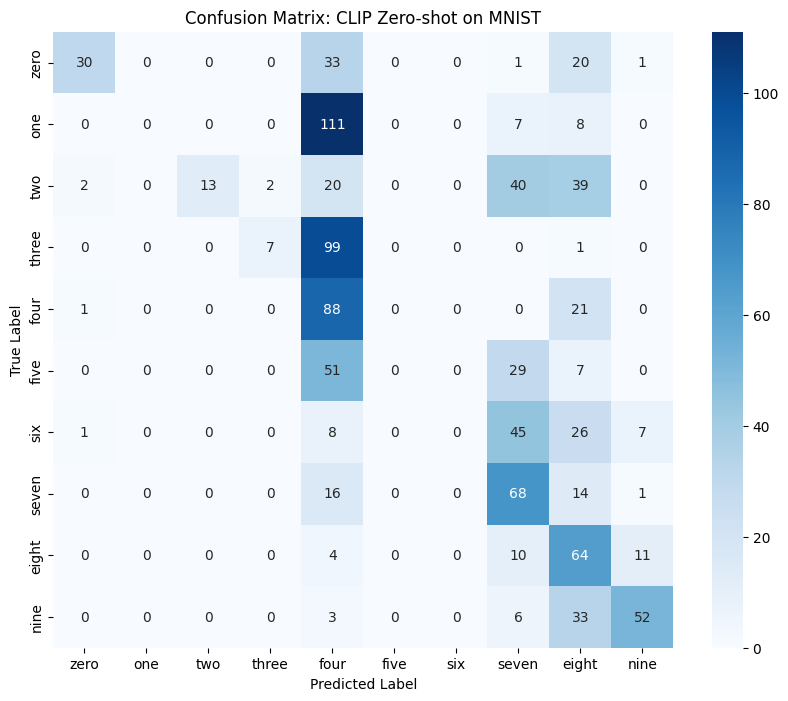

In [9]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix: CLIP Zero-shot on MNIST")
plt.show()

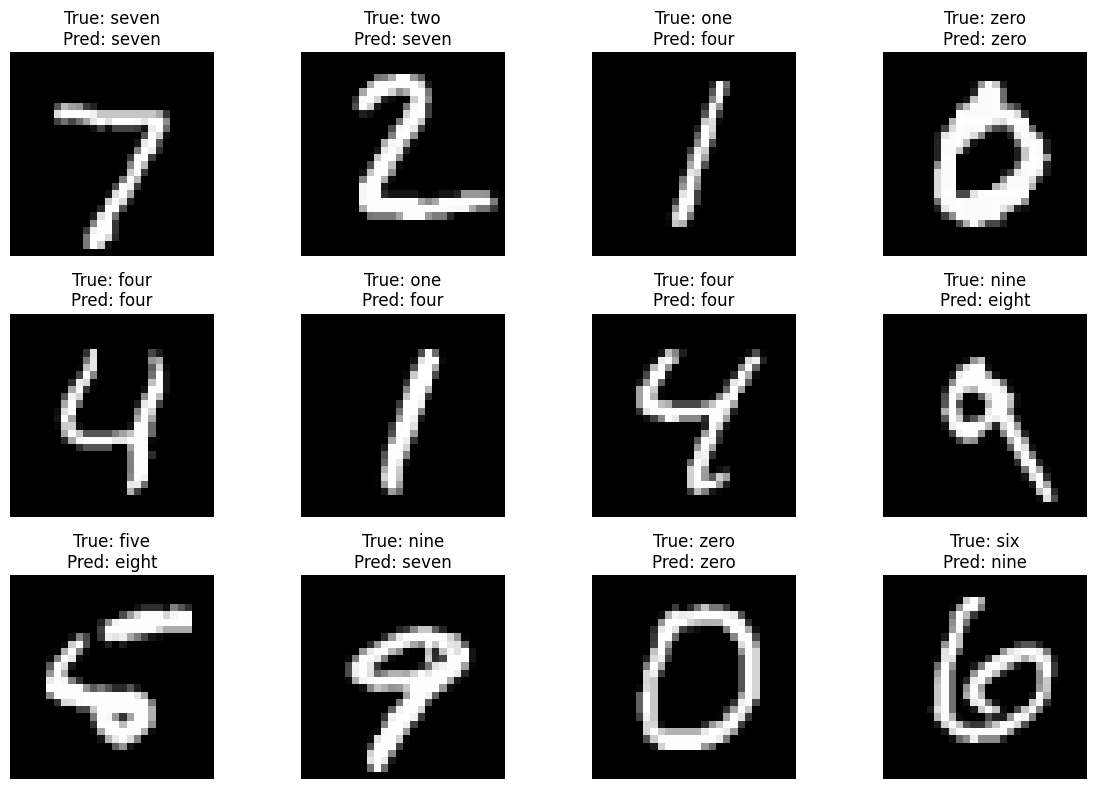

In [10]:
# Load normal MNIST images without CLIP normalization for display
display_dataset = MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

plt.figure(figsize=(12, 8))

for i in range(12):
    image, true_label = display_dataset[i]
    predicted_label = all_predictions[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Question 1 Explanation

In this task, CLIP ViT-B/16 was used for zero-shot classification on the MNIST dataset. The model was not trained on MNIST during this experiment. Instead, text prompts were created for the ten digit classes, such as “a photo of the handwritten digit zero” and “a photo of the handwritten digit one”.

Each MNIST image was resized to 224 × 224 and converted from grayscale to RGB because CLIP expects three-channel image inputs. The image encoder converted each image into an image feature vector, and the text encoder converted each text prompt into a text feature vector. The cosine similarity between image features and text features was then calculated. The class with the highest similarity score was selected as the predicted class.

The performance was evaluated using accuracy, classification report, and confusion matrix. Since CLIP is mainly trained on natural image-text pairs rather than handwritten digit images, the zero-shot performance on MNIST may be limited. However, this experiment demonstrates how CLIP can perform classification without task-specific training.

### Question 1 Result Discussion

The zero-shot CLIP ViT-B/16 model achieved an accuracy of 32.2% on the MNIST test subset. This result is higher than random guessing, which would be around 10% for a 10-class classification problem. However, the accuracy is still limited because CLIP was mainly pretrained on natural image-text pairs, while MNIST contains simple grayscale handwritten digits.

The result shows that CLIP can perform zero-shot classification without training, but its performance depends strongly on how similar the target dataset is to the data seen during pretraining. Since handwritten digits are visually different from natural images, CLIP struggles with some digit classes.

In [11]:
prompt_sets = {
    "basic_digit_name": [
        f"{name}" for name in class_names
    ],
    "handwritten_digit": [
        f"a handwritten digit {name}" for name in class_names
    ],
    "image_of_handwritten_digit": [
        f"an image of the handwritten digit {name}" for name in class_names
    ],
    "mnist_style": [
        f"a black and white image of the handwritten number {name}" for name in class_names
    ]
}

prompt_results = {}

for prompt_name, prompts in prompt_sets.items():
    text_tokens = clip.tokenize(prompts).to(device)

    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    predictions_for_prompt = []
    labels_for_prompt = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            image_features = model.encode_image(images)
            image_features = image_features / image_features.norm(dim=-1, keepdim=True)

            similarity = image_features @ text_features.T
            predictions = similarity.argmax(dim=1)

            predictions_for_prompt.extend(predictions.cpu().numpy())
            labels_for_prompt.extend(labels.numpy())

    acc = accuracy_score(labels_for_prompt, predictions_for_prompt)
    prompt_results[prompt_name] = acc

prompt_results

{'basic_digit_name': 0.484,
 'handwritten_digit': 0.418,
 'image_of_handwritten_digit': 0.365,
 'mnist_style': 0.31}

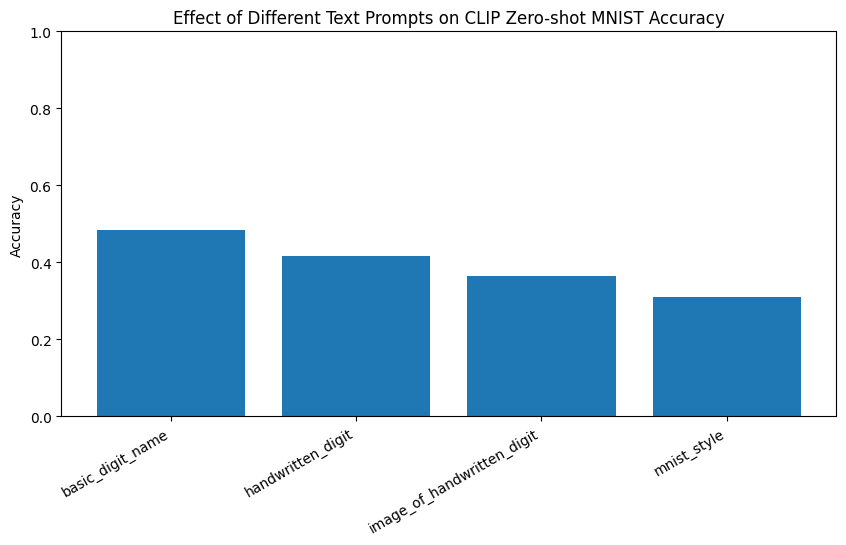

In [12]:
plt.figure(figsize=(10, 5))
plt.bar(prompt_results.keys(), prompt_results.values())
plt.xticks(rotation=30, ha="right")
plt.ylabel("Accuracy")
plt.title("Effect of Different Text Prompts on CLIP Zero-shot MNIST Accuracy")
plt.ylim(0, 1)
plt.show()

### Prompt Comparison

Different text prompts were tested to understand how prompt wording affects CLIP zero-shot performance. Since CLIP compares image features with text features, the wording of the text prompt can influence the final prediction. The experiment shows that prompt engineering is important in zero-shot classification.

Prompts that describe the image more clearly, such as mentioning “handwritten digit” or “black and white image”, can sometimes perform better than using only the class name. This happens because the text description becomes closer to the visual content of the MNIST images.

In [13]:
q1_original_accuracy = accuracy
q1_prompt_results = prompt_results

best_prompt_name = max(prompt_results, key=prompt_results.get)
best_prompt_accuracy = prompt_results[best_prompt_name]

print("Original Question 1 accuracy:", q1_original_accuracy)
print("Best prompt name:", best_prompt_name)
print("Best prompt accuracy:", best_prompt_accuracy)

print("\nAll prompt comparison results:")
for key, value in q1_prompt_results.items():
    print(key, ":", value)

Original Question 1 accuracy: 0.322
Best prompt name: basic_digit_name
Best prompt accuracy: 0.484

All prompt comparison results:
basic_digit_name : 0.484
handwritten_digit : 0.418
image_of_handwritten_digit : 0.365
mnist_style : 0.31


### Final Question 1 Discussion

The original CLIP zero-shot experiment achieved an accuracy of 32.2% on the MNIST test subset. This is better than random guessing, which would be about 10% for 10 digit classes, but the result is still limited because MNIST contains simple grayscale handwritten digits, while CLIP was mainly pretrained on natural image-text pairs.

A prompt comparison experiment was also conducted. The best prompt was `basic_digit_name`, which achieved 48.4% accuracy. This shows that prompt engineering can affect CLIP zero-shot performance. In this case, using simple class names such as “zero”, “one”, and “two” worked better than longer descriptive prompts. This may be because the longer prompts did not match the visual style of MNIST as well as expected.

Overall, CLIP can perform MNIST classification without training, but its performance is lower than a supervised MNIST classifier. This demonstrates both the strength and limitation of zero-shot learning.

## Question 2: CLIP Adapter Fine-tuning on Flickr30k

This task uses a pretrained CLIP image encoder and text encoder. The original encoder parameters are frozen, and small adapter layers are trained using contrastive loss on the Flickr30k image-caption dataset.

In [14]:
!pip install datasets

In [18]:
from datasets import load_dataset

In [20]:
from datasets import load_dataset

# Load one parquet shard of the Flickr30k dataset.
# This is still Flickr30k, but avoids the dataset script error in newer datasets versions.
flickr_dataset = load_dataset(
    "parquet",
    data_files="hf://datasets/nlphuji/flickr30k@refs/convert/parquet/TEST/test/0000.parquet",
    split="train"
)

print(flickr_dataset)
print("Number of examples loaded:", len(flickr_dataset))

TEST/test/0000.parquet:   0%|          | 0.00/506M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
    num_rows: 3800
})
Number of examples loaded: 3800


Keys: dict_keys(['image', 'caption', 'sentids', 'split', 'img_id', 'filename'])
Caption: ['Two young guys with shaggy hair look at their hands while hanging out in the yard.', 'Two young, White males are outside near many bushes.', 'Two men in green shirts are standing in a yard.', 'A man in a blue shirt standing in a garden.', 'Two friends enjoy time spent together.']
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


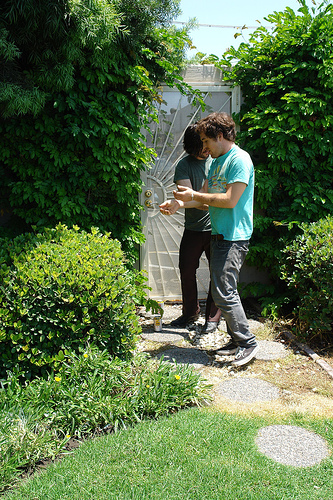

In [21]:
sample = flickr_dataset[0]

print("Keys:", sample.keys())
print("Caption:", sample["caption"])
print("Image type:", type(sample["image"]))

sample["image"]

In [22]:
print(flickr_dataset)

Dataset({
    features: ['image', 'caption', 'sentids', 'split', 'img_id', 'filename'],
    num_rows: 3800
})


3000 images for training
800 images for evaluation

### Preparing Flickr30k for CLIP Training

Each Flickr30k sample contains one image and five captions. For this experiment, the first caption is used for each image-caption pair. The dataset is divided into a training set and an evaluation set.

In [23]:
from torch.utils.data import Dataset, DataLoader, random_split
import random

# We use all 3800 rows from the loaded Flickr30k shard.
# 3000 for training and 800 for evaluation.
train_size = 3000
eval_size = len(flickr_dataset) - train_size

train_data, eval_data = random_split(
    flickr_dataset,
    [train_size, eval_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_data))
print("Evaluation samples:", len(eval_data))

Training samples: 3000
Evaluation samples: 800


In [37]:
class Flickr30kCLIPDataset(Dataset):
    def __init__(self, dataset, preprocess):
        self.dataset = dataset
        self.preprocess = preprocess

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        item = self.dataset[index]

        image = item["image"].convert("RGB")
        captions = item["caption"]

        # Use the first caption for simplicity
        caption = captions[0]

        # CLIP image preprocessing
        image_tensor = self.preprocess(image)

        # CLIP text tokenization
        # truncate=True prevents crash when caption is longer than CLIP's limit
        text_tensor = clip.tokenize(caption, truncate=True).squeeze(0)

        return image_tensor, text_tensor, caption

In [40]:
train_dataset_q2 = Flickr30kCLIPDataset(train_data, preprocess)
eval_dataset_q2 = Flickr30kCLIPDataset(eval_data, preprocess)

train_loader_q2 = DataLoader(
    train_dataset_q2,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

eval_loader_q2 = DataLoader(
    eval_dataset_q2,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Train batches:", len(train_loader_q2))
print("Eval batches:", len(eval_loader_q2))

Train batches: 94
Eval batches: 25


In [42]:
images, texts, captions = next(iter(train_loader_q2))

print("Image batch shape:", images.shape)
print("Text batch shape:", texts.shape)
print("First caption:", captions[0])

Image batch shape: torch.Size([32, 3, 224, 224])
Text batch shape: torch.Size([32, 77])
First caption: A female swimmer in a black bathing suit about to jump off the racing platform into a pool.


### CLIP Adapter Model

The pretrained CLIP image encoder and text encoder are kept frozen. Small adapter networks are added after the image and text features. Only these adapter layers are trained. This allows the model to adapt to the Flickr30k downstream task without updating the full CLIP model.

In [43]:
# Freeze all original CLIP parameters
for param in model.parameters():
    param.requires_grad = False

model.eval()

print("Original CLIP parameters are frozen.")

Original CLIP parameters are frozen.


In [44]:
import torch.nn as nn
import torch.nn.functional as F

class Adapter(nn.Module):
    def __init__(self, feature_dim=512, hidden_dim=256):
        super().__init__()

        self.adapter = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, feature_dim)
        )

    def forward(self, x):
        adapted = self.adapter(x)

        # Residual connection: keep original feature + small learned change
        output = x + adapted

        return output

In [45]:
class CLIPWithAdapters(nn.Module):
    def __init__(self, clip_model, feature_dim=512):
        super().__init__()

        self.clip_model = clip_model

        self.image_adapter = Adapter(feature_dim=feature_dim)
        self.text_adapter = Adapter(feature_dim=feature_dim)

    def forward(self, images, texts):
        # Original CLIP encoders are frozen, so no gradients are needed here
        with torch.no_grad():
            image_features = self.clip_model.encode_image(images).float()
            text_features = self.clip_model.encode_text(texts).float()

        # Apply trainable adapters
        image_features = self.image_adapter(image_features)
        text_features = self.text_adapter(text_features)

        # Normalize features for cosine similarity
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        return image_features, text_features

In [48]:
q2_model = CLIPWithAdapters(model).to(device)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, q2_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 5

print("Q2 model and optimizer reset.")

Q2 model and optimizer reset.


In [49]:
images, texts, captions = next(iter(train_loader_q2))

images = images.to(device)
texts = texts.to(device)

with torch.no_grad():
    image_features, text_features = q2_model(images, texts)

print("Image feature shape:", image_features.shape)
print("Text feature shape:", text_features.shape)

Image feature shape: torch.Size([32, 512])
Text feature shape: torch.Size([32, 512])


In [50]:
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 150146561
Trainable parameters: 525824


### Contrastive Loss for CLIP

The model is trained using contrastive loss. For each batch, the similarity between every image feature and every text feature is calculated. The correct image-caption pairs are located on the diagonal of the similarity matrix. Cross entropy loss is used in both directions: image-to-text and text-to-image.

In [51]:
def clip_contrastive_loss(image_features, text_features, temperature=0.07):
    """
    Computes CLIP-style contrastive loss.

    image_features: tensor of shape [batch_size, feature_dim]
    text_features: tensor of shape [batch_size, feature_dim]
    """

    batch_size = image_features.shape[0]

    # Similarity matrix: each image compared with each text
    logits = image_features @ text_features.T

    # Temperature scaling
    logits = logits / temperature

    # Correct pairs are on the diagonal
    labels = torch.arange(batch_size).to(device)

    # Image-to-text loss
    loss_i2t = F.cross_entropy(logits, labels)

    # Text-to-image loss
    loss_t2i = F.cross_entropy(logits.T, labels)

    # Final loss
    loss = (loss_i2t + loss_t2i) / 2

    return loss

In [52]:
images, texts, captions = next(iter(train_loader_q2))

images = images.to(device)
texts = texts.to(device)

image_features, text_features = q2_model(images, texts)

test_loss = clip_contrastive_loss(image_features, text_features)

print("Test contrastive loss:", test_loss.item())

Test contrastive loss: 1.5872191190719604


### Training the CLIP Adapters

Only the adapter layers are trained. The original CLIP image encoder and text encoder remain frozen. The optimizer updates only the parameters where `requires_grad=True`.

In [53]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, q2_model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

num_epochs = 5

print("Optimizer created.")
print("Number of epochs:", num_epochs)

Optimizer created.
Number of epochs: 5


In [54]:
train_losses_q2 = []

for epoch in range(num_epochs):
    q2_model.train()
    total_loss = 0

    for batch_idx, (images, texts, captions) in enumerate(train_loader_q2):
        images = images.to(device)
        texts = texts.to(device)

        image_features, text_features = q2_model(images, texts)
        loss = clip_contrastive_loss(image_features, text_features)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 20 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}], "
                f"Batch [{batch_idx+1}/{len(train_loader_q2)}], "
                f"Loss: {loss.item():.4f}"
            )

    average_loss = total_loss / len(train_loader_q2)
    train_losses_q2.append(average_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] Average Loss: {average_loss:.4f}")

Epoch [1/5], Batch [20/94], Loss: 1.3313
Epoch [1/5], Batch [40/94], Loss: 1.4232
Epoch [1/5], Batch [60/94], Loss: 1.1854
Epoch [1/5], Batch [80/94], Loss: 1.1441
Epoch [1/5] Average Loss: 1.2918
Epoch [2/5], Batch [20/94], Loss: 0.8467
Epoch [2/5], Batch [40/94], Loss: 0.7231
Epoch [2/5], Batch [60/94], Loss: 0.6015
Epoch [2/5], Batch [80/94], Loss: 0.5440
Epoch [2/5] Average Loss: 0.7161
Epoch [3/5], Batch [20/94], Loss: 0.5011
Epoch [3/5], Batch [40/94], Loss: 0.3838
Epoch [3/5], Batch [60/94], Loss: 0.4556
Epoch [3/5], Batch [80/94], Loss: 0.4758
Epoch [3/5] Average Loss: 0.4581
Epoch [4/5], Batch [20/94], Loss: 0.3636
Epoch [4/5], Batch [40/94], Loss: 0.4161
Epoch [4/5], Batch [60/94], Loss: 0.2501
Epoch [4/5], Batch [80/94], Loss: 0.3188
Epoch [4/5] Average Loss: 0.3576
Epoch [5/5], Batch [20/94], Loss: 0.2540
Epoch [5/5], Batch [40/94], Loss: 0.2519
Epoch [5/5], Batch [60/94], Loss: 0.3637
Epoch [5/5], Batch [80/94], Loss: 0.2465
Epoch [5/5] Average Loss: 0.3098


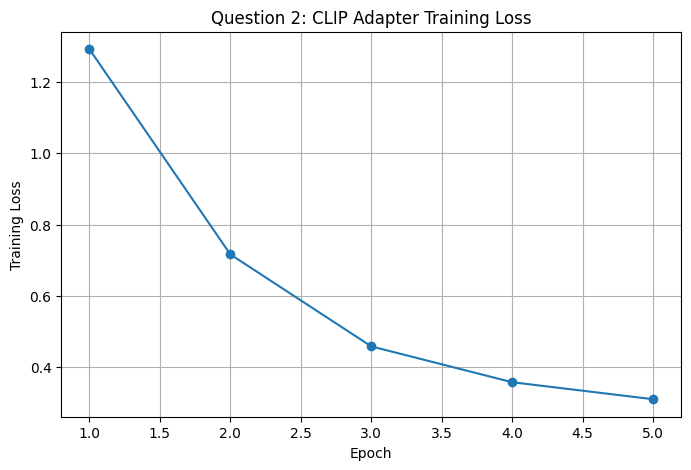

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_losses_q2, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Question 2: CLIP Adapter Training Loss")
plt.grid(True)
plt.show()

### Evaluation of CLIP Adapter Model

The trained adapter model is evaluated using image-text retrieval. For each image in the evaluation set, the model calculates similarity scores against all captions. If the correct caption has the highest similarity, it is counted as correct. The same process is also done in the reverse direction, where each caption retrieves the most similar image.

In [56]:
def extract_features_for_evaluation(model, dataloader):
    model.eval()

    all_image_features = []
    all_text_features = []
    all_captions = []

    with torch.no_grad():
        for images, texts, captions in dataloader:
            images = images.to(device)
            texts = texts.to(device)

            image_features, text_features = model(images, texts)

            all_image_features.append(image_features.cpu())
            all_text_features.append(text_features.cpu())
            all_captions.extend(captions)

    all_image_features = torch.cat(all_image_features, dim=0)
    all_text_features = torch.cat(all_text_features, dim=0)

    return all_image_features, all_text_features, all_captions


eval_image_features, eval_text_features, eval_captions = extract_features_for_evaluation(
    q2_model,
    eval_loader_q2
)

print("Evaluation image features:", eval_image_features.shape)
print("Evaluation text features:", eval_text_features.shape)
print("Number of captions:", len(eval_captions))

Evaluation image features: torch.Size([800, 512])
Evaluation text features: torch.Size([800, 512])
Number of captions: 800


In [57]:
similarity_matrix = eval_image_features @ eval_text_features.T

num_samples = similarity_matrix.shape[0]
targets = torch.arange(num_samples)

# Image-to-text retrieval
image_to_text_top1 = similarity_matrix.argmax(dim=1)
image_to_text_accuracy = (image_to_text_top1 == targets).float().mean().item()

# Text-to-image retrieval
text_to_image_top1 = similarity_matrix.argmax(dim=0)
text_to_image_accuracy = (text_to_image_top1 == targets).float().mean().item()

print("Image-to-text Top-1 Accuracy:", image_to_text_accuracy)
print("Text-to-image Top-1 Accuracy:", text_to_image_accuracy)

Image-to-text Top-1 Accuracy: 0.7574999928474426
Text-to-image Top-1 Accuracy: 0.7250000238418579


In [58]:
# Image-to-text Recall@5
image_to_text_top5 = similarity_matrix.topk(5, dim=1).indices
image_to_text_recall5 = (
    image_to_text_top5 == targets.unsqueeze(1)
).any(dim=1).float().mean().item()

# Text-to-image Recall@5
text_to_image_top5 = similarity_matrix.topk(5, dim=0).indices
text_to_image_recall5 = (
    text_to_image_top5 == targets.unsqueeze(0)
).any(dim=0).float().mean().item()

print("Image-to-text Recall@5:", image_to_text_recall5)
print("Text-to-image Recall@5:", text_to_image_recall5)

Image-to-text Recall@5: 0.9362499713897705
Text-to-image Recall@5: 0.9325000047683716


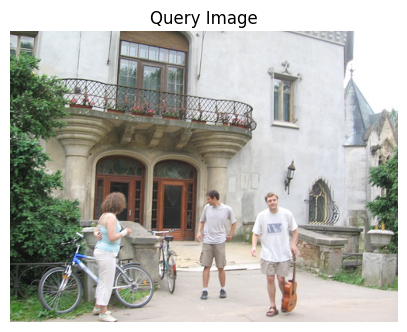

Correct caption:
A girl stands next to a bike parked in front of a building while two men, one
carrying a guitar, walk by.

Top 3 retrieved captions:

Rank 1:
A group of people wearing blue shirts stand outside in front of a tree.

Rank 2:
A girl stands next to a bike parked in front of a building while two men, one
carrying a guitar, walk by.

Rank 3:
A group of people are standing and conversing inside of a building.


In [59]:
import textwrap

def show_image_to_text_retrieval(index):
    image_item = eval_data[index]
    image = image_item["image"]

    similarities = similarity_matrix[index]
    top_indices = similarities.topk(3).indices.tolist()

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Query Image")
    plt.show()

    print("Correct caption:")
    print(textwrap.fill(eval_captions[index], width=80))

    print("\nTop 3 retrieved captions:")
    for rank, caption_index in enumerate(top_indices, start=1):
        print(f"\nRank {rank}:")
        print(textwrap.fill(eval_captions[caption_index], width=80))


show_image_to_text_retrieval(0)

In [62]:
q2_results = {
    "image_to_text_top1": image_to_text_accuracy,
    "text_to_image_top1": text_to_image_accuracy,
    "image_to_text_recall5": image_to_text_recall5,
    "text_to_image_recall5": text_to_image_recall5,
    "final_training_loss": train_losses_q2[-1]
}

q2_results
print("Question 2 Results")
print("------------------")
print("Image-to-text Top-1 Accuracy:", q2_results["image_to_text_top1"])
print("Text-to-image Top-1 Accuracy:", q2_results["text_to_image_top1"])
print("Image-to-text Recall@5:", q2_results["image_to_text_recall5"])
print("Text-to-image Recall@5:", q2_results["text_to_image_recall5"])
print("Final Training Loss:", q2_results["final_training_loss"])

Question 2 Results
------------------
Image-to-text Top-1 Accuracy: 0.7574999928474426
Text-to-image Top-1 Accuracy: 0.7250000238418579
Image-to-text Recall@5: 0.9362499713897705
Text-to-image Recall@5: 0.9325000047683716
Final Training Loss: 0.30983662082159774


### Question 2 Result Discussion

In this task, a CLIP-based multi-modal model was trained on the Flickr30k dataset. The pretrained CLIP image encoder and text encoder were kept frozen, and only small adapter networks were trained. This follows the transfer learning approach where the pretrained model keeps its general image-text knowledge, while the adapters learn task-specific changes for the Flickr30k dataset.

The model was trained using contrastive loss. In each batch, the similarity between every image and every caption was calculated. The correct image-caption pairs were placed on the diagonal of the similarity matrix. Cross entropy loss was applied in both directions: image-to-text and text-to-image.

The training loss decreased from 1.2918 in epoch 1 to 0.3098 in epoch 5. This shows that the adapters successfully learned to improve the alignment between image features and text features.

For evaluation, image-text retrieval was used. The image-to-text Top-1 accuracy was 75.75%, and the text-to-image Top-1 accuracy was 72.50%. The Recall@5 results were also high, with 93.62% for image-to-text and 93.25% for text-to-image. These results show that the trained adapter model can correctly retrieve matching captions and images most of the time.

Overall, the experiment shows that CLIP can be adapted to a downstream multi-modal task by freezing the pretrained encoders and training lightweight adapter layers.

## Question 3: Transfer Learning using Pretrained VGG16 on Fashion-MNIST

In this task, a pretrained VGG16 model is used for Fashion-MNIST classification. The convolutional layers are frozen because they already contain useful visual features learned from ImageNet. The classifier part is replaced with new layers suitable for the 10 Fashion-MNIST classes. Only the new classifier layers are trained.

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [64]:
fashion_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

fashion_train_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=fashion_transform
)

fashion_test_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=fashion_transform
)

class_names_fashion = fashion_train_full.classes

print("Fashion-MNIST classes:")
print(class_names_fashion)
print("Training samples:", len(fashion_train_full))
print("Testing samples:", len(fashion_test_full))

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.70MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.5MB/s]


Fashion-MNIST classes:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Training samples: 60000
Testing samples: 10000


In [65]:
q3_train_subset = Subset(fashion_train_full, range(10000))
q3_test_subset = Subset(fashion_test_full, range(2000))

q3_train_loader = DataLoader(
    q3_train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

q3_test_loader = DataLoader(
    q3_test_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Q3 training samples:", len(q3_train_subset))
print("Q3 testing samples:", len(q3_test_subset))
print("Q3 train batches:", len(q3_train_loader))
print("Q3 test batches:", len(q3_test_loader))

Q3 training samples: 10000
Q3 testing samples: 2000
Q3 train batches: 313
Q3 test batches: 63


In [66]:
images, labels = next(iter(q3_train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Example label:", labels[0].item())
print("Example class:", class_names_fashion[labels[0].item()])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Example label: 3
Example class: Dress


In [68]:
# Load pretrained VGG16 model
vgg16_pretrained = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

print(vgg16_pretrained)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [69]:
# Freeze all pretrained VGG16 parameters
for param in vgg16_pretrained.parameters():
    param.requires_grad = False

print("All pretrained VGG16 parameters are frozen.")

All pretrained VGG16 parameters are frozen.


In [70]:
# Replace the classifier for Fashion-MNIST 10 classes
vgg16_pretrained.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10)
)

vgg16_pretrained = vgg16_pretrained.to(device)

print("VGG16 classifier replaced for Fashion-MNIST.")

VGG16 classifier replaced for Fashion-MNIST.


In [71]:
q3_trainable_params = sum(
    p.numel() for p in vgg16_pretrained.parameters() if p.requires_grad
)

q3_total_params = sum(
    p.numel() for p in vgg16_pretrained.parameters()
)

print("Total parameters:", q3_total_params)
print("Trainable parameters:", q3_trainable_params)

Total parameters: 27565386
Trainable parameters: 12850698


In [72]:
criterion_q3 = nn.CrossEntropyLoss()

optimizer_q3 = optim.Adam(
    filter(lambda p: p.requires_grad, vgg16_pretrained.parameters()),
    lr=1e-4
)

num_epochs_q3 = 3

print("Loss function and optimizer created.")

Loss function and optimizer created.


In [73]:
q3_train_losses = []

for epoch in range(num_epochs_q3):
    vgg16_pretrained.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(q3_train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg16_pretrained(images)
        loss = criterion_q3(outputs, labels)

        optimizer_q3.zero_grad()
        loss.backward()
        optimizer_q3.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs_q3}], "
                f"Batch [{batch_idx+1}/{len(q3_train_loader)}], "
                f"Loss: {loss.item():.4f}"
            )

    average_loss = running_loss / len(q3_train_loader)
    q3_train_losses.append(average_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_q3}] Average Loss: {average_loss:.4f}")

Epoch [1/3], Batch [50/313], Loss: 0.7694
Epoch [1/3], Batch [100/313], Loss: 0.4890
Epoch [1/3], Batch [150/313], Loss: 0.1843
Epoch [1/3], Batch [200/313], Loss: 0.1158
Epoch [1/3], Batch [250/313], Loss: 0.2336
Epoch [1/3], Batch [300/313], Loss: 0.2412
Epoch [1/3] Average Loss: 0.4313
Epoch [2/3], Batch [50/313], Loss: 0.2595
Epoch [2/3], Batch [100/313], Loss: 0.2143
Epoch [2/3], Batch [150/313], Loss: 0.1778
Epoch [2/3], Batch [200/313], Loss: 0.2141
Epoch [2/3], Batch [250/313], Loss: 0.2242
Epoch [2/3], Batch [300/313], Loss: 0.3639
Epoch [2/3] Average Loss: 0.2080
Epoch [3/3], Batch [50/313], Loss: 0.3656
Epoch [3/3], Batch [100/313], Loss: 0.1258
Epoch [3/3], Batch [150/313], Loss: 0.2945
Epoch [3/3], Batch [200/313], Loss: 0.1237
Epoch [3/3], Batch [250/313], Loss: 0.0522
Epoch [3/3], Batch [300/313], Loss: 0.1114
Epoch [3/3] Average Loss: 0.1358


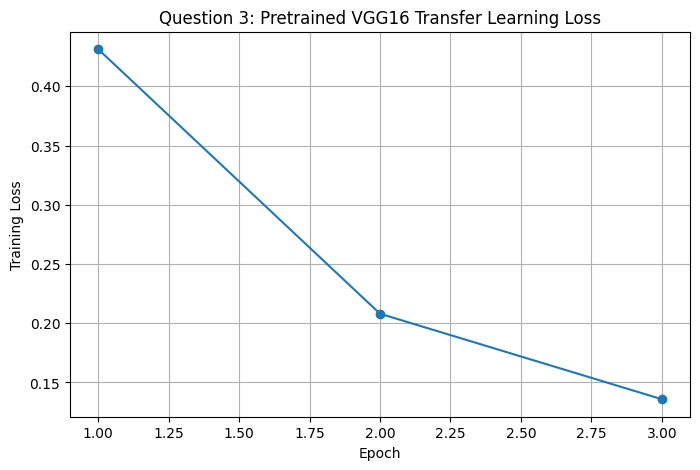

In [74]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_q3 + 1), q3_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Question 3: Pretrained VGG16 Transfer Learning Loss")
plt.grid(True)
plt.show()

In [75]:
vgg16_pretrained.eval()

q3_all_predictions = []
q3_all_labels = []

with torch.no_grad():
    for images, labels in q3_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg16_pretrained(images)
        predictions = torch.argmax(outputs, dim=1)

        q3_all_predictions.extend(predictions.cpu().numpy())
        q3_all_labels.extend(labels.cpu().numpy())

q3_test_accuracy = accuracy_score(q3_all_labels, q3_all_predictions)

print("Question 3 Test Accuracy:", q3_test_accuracy)

Question 3 Test Accuracy: 0.915


In [76]:
print(classification_report(
    q3_all_labels,
    q3_all_predictions,
    target_names=class_names_fashion
))

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.93      0.86       200
     Trouser       1.00      0.99      1.00       203
    Pullover       0.94      0.88      0.91       214
       Dress       0.89      0.91      0.90       190
        Coat       0.92      0.83      0.87       219
      Sandal       0.99      0.96      0.97       195
       Shirt       0.74      0.76      0.75       197
     Sneaker       0.94      0.97      0.96       200
         Bag       0.99      0.96      0.98       194
  Ankle boot       0.97      0.97      0.97       188

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



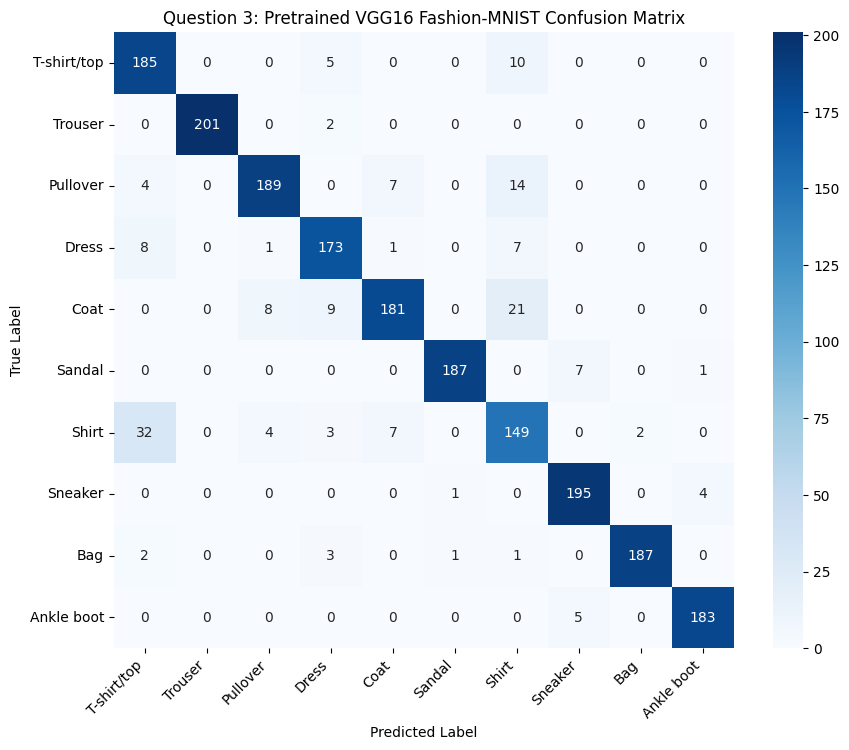

In [77]:
q3_cm = confusion_matrix(q3_all_labels, q3_all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    q3_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names_fashion,
    yticklabels=class_names_fashion,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Question 3: Pretrained VGG16 Fashion-MNIST Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [78]:
q3_results = {
    "method": "Pretrained VGG16 transfer learning",
    "trainable_layers": "New classifier layers only",
    "final_training_loss": q3_train_losses[-1],
    "test_accuracy": q3_test_accuracy
}

q3_results

{'method': 'Pretrained VGG16 transfer learning',
 'trainable_layers': 'New classifier layers only',
 'final_training_loss': 0.13581047297273866,
 'test_accuracy': 0.915}

### Question 3 Result Discussion

The pretrained VGG16 transfer learning model achieved a test accuracy of 91.5% on the Fashion-MNIST test subset. The final training loss was 0.1358.

In this experiment, the convolutional feature extraction layers of VGG16 were frozen, and only the newly replaced classifier layers were trained. This allowed the model to use visual features learned from ImageNet while adapting the final classifier to the 10 Fashion-MNIST classes.

The high accuracy shows that pretrained models can be effective even when the target dataset is different from the original pretraining dataset. Although ImageNet contains natural RGB images and Fashion-MNIST contains grayscale clothing images, the pretrained VGG16 features still provide useful visual representations such as edges, shapes, and textures.

## Question 4: VGG16 Trained From Scratch on Fashion-MNIST

In this task, an untrained VGG16-style model is created for Fashion-MNIST classification. Unlike Question 3, no pretrained ImageNet weights are used. All layers are trained from scratch on the Fashion-MNIST dataset.

The model is adapted for 28 × 28 grayscale images and 10 output classes.

In [79]:
q4_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

q4_train_full = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=q4_transform
)

q4_test_full = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=q4_transform
)

q4_train_subset = Subset(q4_train_full, range(10000))
q4_test_subset = Subset(q4_test_full, range(2000))

q4_train_loader = DataLoader(
    q4_train_subset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

q4_test_loader = DataLoader(
    q4_test_subset,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

print("Q4 training samples:", len(q4_train_subset))
print("Q4 testing samples:", len(q4_test_subset))

Q4 training samples: 10000
Q4 testing samples: 2000


In [80]:
images, labels = next(iter(q4_train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


In [81]:
class VGG16ScratchFashionMNIST(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [82]:
vgg16_scratch = VGG16ScratchFashionMNIST(num_classes=10).to(device)

criterion_q4 = nn.CrossEntropyLoss()

optimizer_q4 = optim.Adam(
    vgg16_scratch.parameters(),
    lr=1e-4
)

num_epochs_q4 = 5

q4_total_params = sum(p.numel() for p in vgg16_scratch.parameters())
q4_trainable_params = sum(p.numel() for p in vgg16_scratch.parameters() if p.requires_grad)

print("Total parameters:", q4_total_params)
print("Trainable parameters:", q4_trainable_params)
print("Number of epochs:", num_epochs_q4)

Total parameters: 15110090
Trainable parameters: 15110090
Number of epochs: 5


In [83]:
q4_train_losses = []

for epoch in range(num_epochs_q4):
    vgg16_scratch.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(q4_train_loader):
        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg16_scratch(images)
        loss = criterion_q4(outputs, labels)

        optimizer_q4.zero_grad()
        loss.backward()
        optimizer_q4.step()

        running_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs_q4}], "
                f"Batch [{batch_idx+1}/{len(q4_train_loader)}], "
                f"Loss: {loss.item():.4f}"
            )

    average_loss = running_loss / len(q4_train_loader)
    q4_train_losses.append(average_loss)

    print(f"Epoch [{epoch+1}/{num_epochs_q4}] Average Loss: {average_loss:.4f}")

Epoch [1/5], Batch [50/157], Loss: 2.3003
Epoch [1/5], Batch [100/157], Loss: 2.0350
Epoch [1/5], Batch [150/157], Loss: 1.8872
Epoch [1/5] Average Loss: 2.1597
Epoch [2/5], Batch [50/157], Loss: 1.7728
Epoch [2/5], Batch [100/157], Loss: 1.1283
Epoch [2/5], Batch [150/157], Loss: 1.2370
Epoch [2/5] Average Loss: 1.6046
Epoch [3/5], Batch [50/157], Loss: 1.2707
Epoch [3/5], Batch [100/157], Loss: 1.1320
Epoch [3/5], Batch [150/157], Loss: 1.1120
Epoch [3/5] Average Loss: 1.1771
Epoch [4/5], Batch [50/157], Loss: 0.8944
Epoch [4/5], Batch [100/157], Loss: 0.7386
Epoch [4/5], Batch [150/157], Loss: 0.8883
Epoch [4/5] Average Loss: 0.9736
Epoch [5/5], Batch [50/157], Loss: 0.8886
Epoch [5/5], Batch [100/157], Loss: 0.6352
Epoch [5/5], Batch [150/157], Loss: 0.9138
Epoch [5/5] Average Loss: 0.8747


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_q4 + 1), q4_train_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Question 4: VGG16 From Scratch Training Loss")
plt.grid(True)
plt.show()

In [84]:
vgg16_scratch.eval()

q4_all_predictions = []
q4_all_labels = []

with torch.no_grad():
    for images, labels in q4_test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = vgg16_scratch(images)
        predictions = torch.argmax(outputs, dim=1)

        q4_all_predictions.extend(predictions.cpu().numpy())
        q4_all_labels.extend(labels.cpu().numpy())

q4_test_accuracy = accuracy_score(q4_all_labels, q4_all_predictions)

print("Question 4 Test Accuracy:", q4_test_accuracy)

Question 4 Test Accuracy: 0.6615


In [85]:
print(classification_report(
    q4_all_labels,
    q4_all_predictions,
    target_names=class_names_fashion
))

              precision    recall  f1-score   support

 T-shirt/top       0.64      0.81      0.71       200
     Trouser       0.91      0.98      0.94       203
    Pullover       0.33      0.76      0.46       214
       Dress       0.68      0.84      0.75       190
        Coat       0.46      0.19      0.27       219
      Sandal       0.93      0.89      0.91       195
       Shirt       0.30      0.10      0.15       197
     Sneaker       0.86      0.92      0.88       200
         Bag       0.81      0.24      0.37       194
  Ankle boot       0.92      0.94      0.93       188

    accuracy                           0.66      2000
   macro avg       0.68      0.67      0.64      2000
weighted avg       0.68      0.66      0.63      2000



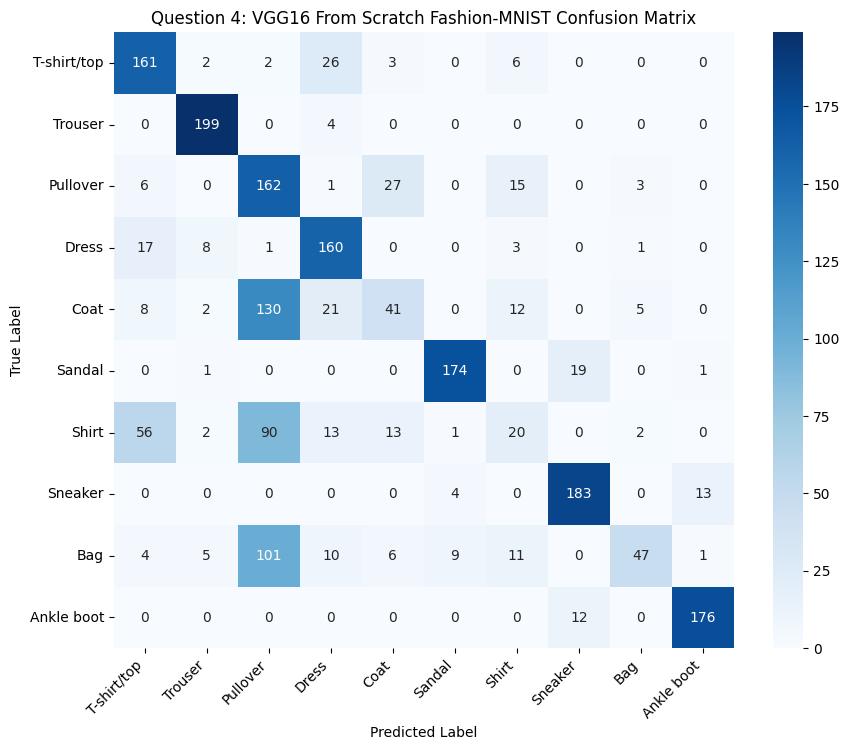

In [86]:
q4_cm = confusion_matrix(q4_all_labels, q4_all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    q4_cm,
    annot=True,
    fmt="d",
    xticklabels=class_names_fashion,
    yticklabels=class_names_fashion,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Question 4: VGG16 From Scratch Fashion-MNIST Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

In [87]:
q4_results = {
    "method": "VGG16-style model trained from scratch",
    "trainable_layers": "All layers",
    "final_training_loss": q4_train_losses[-1],
    "test_accuracy": q4_test_accuracy
}

q4_results

{'method': 'VGG16-style model trained from scratch',
 'trainable_layers': 'All layers',
 'final_training_loss': 0.8746892407441594,
 'test_accuracy': 0.6615}

## Question 5: Comparison Between Transfer Learning and Training From Scratch

This question compares the results from Question 3 and Question 4. Question 3 used pretrained VGG16 with frozen feature extraction layers and trained only the new classifier layers. Question 4 used an untrained VGG16-style model and trained all parameters from scratch.

In [88]:
q5_methods = [
    "Pretrained VGG16\nTransfer Learning",
    "VGG16 From Scratch"
]

q5_accuracies = [
    q3_results["test_accuracy"],
    q4_results["test_accuracy"]
]

q5_losses = [
    q3_results["final_training_loss"],
    q4_results["final_training_loss"]
]

print("Question 5 Comparison")
print("---------------------")
print("Q3 Transfer Learning Accuracy:", q3_results["test_accuracy"])
print("Q4 From Scratch Accuracy:", q4_results["test_accuracy"])
print("Accuracy Difference:", q3_results["test_accuracy"] - q4_results["test_accuracy"])
print()
print("Q3 Final Training Loss:", q3_results["final_training_loss"])
print("Q4 Final Training Loss:", q4_results["final_training_loss"])

Question 5 Comparison
---------------------
Q3 Transfer Learning Accuracy: 0.915
Q4 From Scratch Accuracy: 0.6615
Accuracy Difference: 0.25350000000000006

Q3 Final Training Loss: 0.13581047297273866
Q4 Final Training Loss: 0.8746892407441594


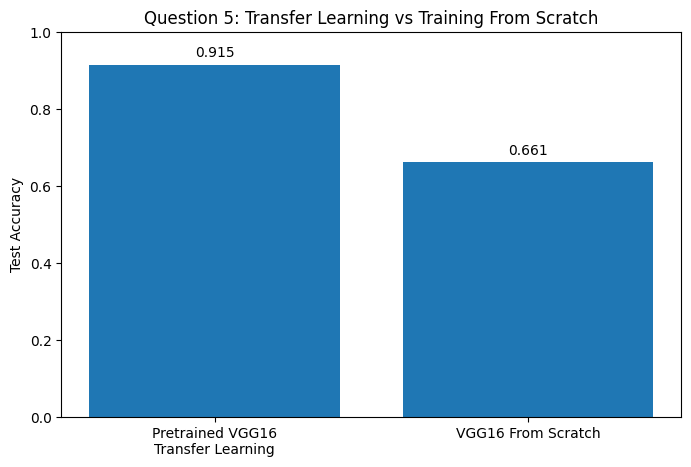

In [89]:
plt.figure(figsize=(8, 5))
plt.bar(q5_methods, q5_accuracies)
plt.ylabel("Test Accuracy")
plt.title("Question 5: Transfer Learning vs Training From Scratch")
plt.ylim(0, 1)

for i, acc in enumerate(q5_accuracies):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha="center")

plt.show()

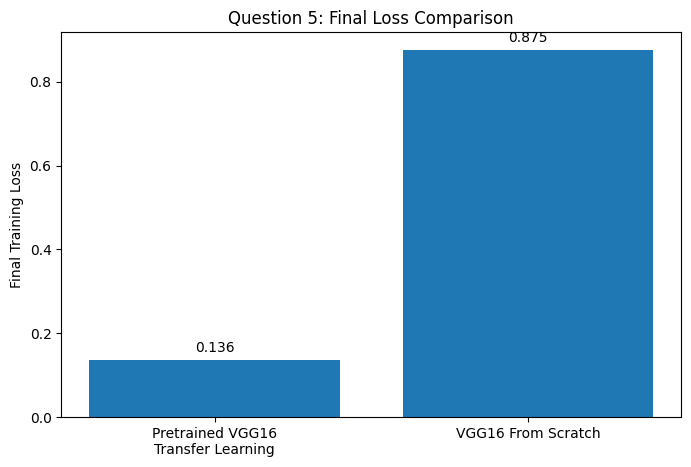

In [90]:
plt.figure(figsize=(8, 5))
plt.bar(q5_methods, q5_losses)
plt.ylabel("Final Training Loss")
plt.title("Question 5: Final Loss Comparison")

for i, loss in enumerate(q5_losses):
    plt.text(i, loss + 0.02, f"{loss:.3f}", ha="center")

plt.show()

### Question 5 Discussion

The transfer learning approach in Question 3 gave a better result than the model trained from scratch in Question 4.

The pretrained VGG16 transfer learning model achieved a test accuracy of 91.5%, while the VGG16-style model trained from scratch achieved a test accuracy of 66.15%. Therefore, transfer learning performed better by 25.35 percentage points.

The main reason for this improvement is that the pretrained VGG16 model had already learned useful visual features from ImageNet. These features include simple patterns such as edges, corners, curves, textures, and more complex object parts. Even though Fashion-MNIST is different from ImageNet, these general visual features are still useful for recognising clothing categories.

In Question 3, only the new classifier layers were trained, while the pretrained convolutional layers were frozen. This made training faster and more stable because the model did not need to learn all visual features from the beginning.

In Question 4, the model started with random weights and had to learn all features only from the Fashion-MNIST training subset. Since deep networks such as VGG16 have many parameters, training from scratch usually requires more data, more epochs, and more computation. Because only a subset of Fashion-MNIST and 5 epochs were used, the scratch model did not reach the same performance as the pretrained model.

Overall, the result shows that transfer learning is more effective than training from scratch when the dataset is limited and computation time is restricted.

## Question 6: Generative Adversarial Network on Fashion-MNIST

In this task, a Generative Adversarial Network is trained to generate Fashion-MNIST-like images. The GAN contains two networks: a generator and a discriminator.

The generator takes random noise as input and tries to create fake clothing images. The discriminator receives both real Fashion-MNIST images and fake generated images and tries to classify them as real or fake.

Both networks are trained together. The generator improves by trying to fool the discriminator, while the discriminator improves by learning to distinguish real images from generated images.

In [91]:
import os
from torchvision.utils import save_image, make_grid

generated_folder = "generated_fashion_images"
os.makedirs(generated_folder, exist_ok=True)

print("Generated image folder created:", generated_folder)

Generated image folder created: generated_fashion_images


In [92]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(noise_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        return self.model(z)

In [93]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1)
        )

    def forward(self, x):
        return self.model(x)

In [94]:
noise_dim = 100

generator = Generator(noise_dim=noise_dim).to(device)
discriminator = Discriminator().to(device)

criterion_gan = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

print("Generator and Discriminator created.")
print("Generator parameters:", sum(p.numel() for p in generator.parameters()))
print("Discriminator parameters:", sum(p.numel() for p in discriminator.parameters()))

Generator and Discriminator created.
Generator parameters: 778305
Discriminator parameters: 138817


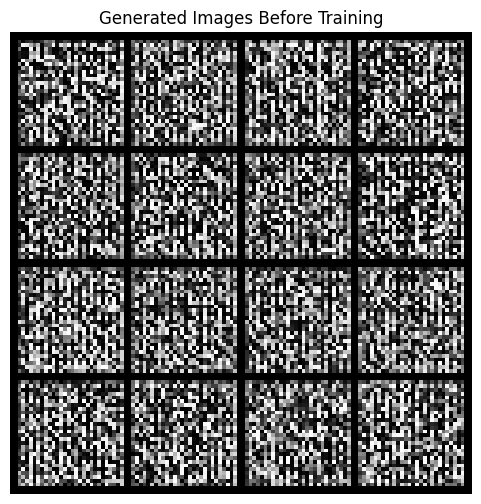

In [95]:
fixed_noise = torch.randn(16, noise_dim, device=device)

with torch.no_grad():
    fake_images_before = generator(fixed_noise).cpu()

grid = make_grid(fake_images_before, nrow=4, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated Images Before Training")
plt.show()

In [96]:
num_epochs_q6 = 10

generator_losses = []
discriminator_losses = []

for epoch in range(num_epochs_q6):
    generator.train()
    discriminator.train()

    total_g_loss = 0.0
    total_d_loss = 0.0

    for batch_idx, (real_images, _) in enumerate(q4_train_loader):
        real_images = real_images.to(device)
        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # -------------------------
        # Train Discriminator
        # -------------------------
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_images = generator(noise)

        real_outputs = discriminator(real_images)
        fake_outputs = discriminator(fake_images.detach())

        d_loss_real = criterion_gan(real_outputs, real_labels)
        d_loss_fake = criterion_gan(fake_outputs, fake_labels)

        d_loss = d_loss_real + d_loss_fake

        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        # -------------------------
        # Train Generator
        # -------------------------
        noise = torch.randn(batch_size, noise_dim, device=device)
        fake_images = generator(noise)

        fake_outputs = discriminator(fake_images)

        # Generator wants discriminator to classify fake images as real
        g_loss = criterion_gan(fake_outputs, real_labels)

        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

        total_d_loss += d_loss.item()
        total_g_loss += g_loss.item()

    avg_d_loss = total_d_loss / len(q4_train_loader)
    avg_g_loss = total_g_loss / len(q4_train_loader)

    discriminator_losses.append(avg_d_loss)
    generator_losses.append(avg_g_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs_q6}] "
        f"D Loss: {avg_d_loss:.4f}, G Loss: {avg_g_loss:.4f}"
    )

    # Save generated images every epoch
    with torch.no_grad():
        generated_images = generator(fixed_noise).cpu()

    save_image(
        generated_images,
        f"{generated_folder}/epoch_{epoch+1}.png",
        nrow=4,
        normalize=True
    )

Epoch [1/10] D Loss: 0.2626, G Loss: 3.1971
Epoch [2/10] D Loss: 0.4392, G Loss: 2.1299
Epoch [3/10] D Loss: 0.2294, G Loss: 2.6822
Epoch [4/10] D Loss: 0.2283, G Loss: 2.9728
Epoch [5/10] D Loss: 0.3122, G Loss: 2.8606
Epoch [6/10] D Loss: 0.3174, G Loss: 2.6613
Epoch [7/10] D Loss: 0.2970, G Loss: 2.7051
Epoch [8/10] D Loss: 0.2652, G Loss: 2.8647
Epoch [9/10] D Loss: 0.2608, G Loss: 2.9813
Epoch [10/10] D Loss: 0.2871, G Loss: 2.9011


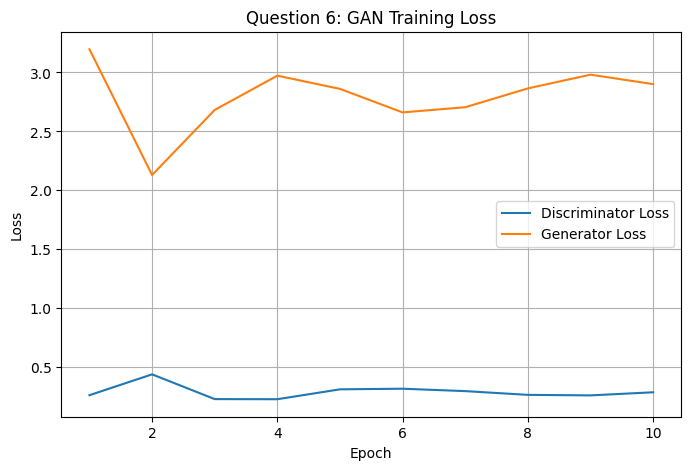

In [97]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs_q6 + 1), discriminator_losses, label="Discriminator Loss")
plt.plot(range(1, num_epochs_q6 + 1), generator_losses, label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Question 6: GAN Training Loss")
plt.legend()
plt.grid(True)
plt.show()

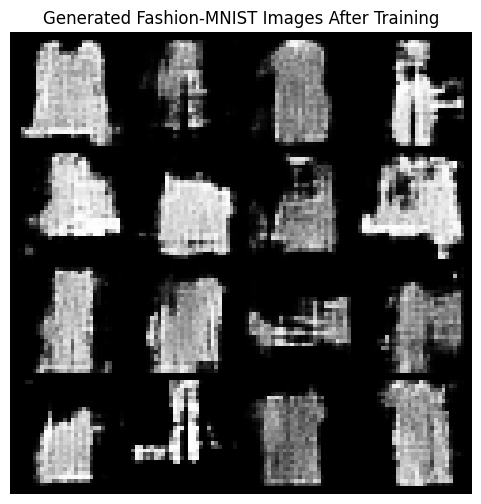

In [98]:
with torch.no_grad():
    final_generated_images = generator(fixed_noise).cpu()

grid = make_grid(final_generated_images, nrow=4, normalize=True)

plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated Fashion-MNIST Images After Training")
plt.show()

In [99]:
import os

saved_files = os.listdir(generated_folder)
saved_files = sorted(saved_files)

print("Saved generated image files:")
for file in saved_files:
    print(file)

Saved generated image files:
epoch_1.png
epoch_10.png
epoch_2.png
epoch_3.png
epoch_4.png
epoch_5.png
epoch_6.png
epoch_7.png
epoch_8.png
epoch_9.png


### Question 6 Result Discussion

A Generative Adversarial Network was implemented to generate Fashion-MNIST-like images. The generator takes random noise as input and produces fake grayscale clothing images. The discriminator receives both real Fashion-MNIST images and generated fake images and learns to classify them as real or fake.

The GAN was trained for 10 epochs. The discriminator loss and generator loss changed during training because both networks were competing with each other. Unlike normal classification models, GAN losses do not always decrease smoothly. This is because the generator improves by trying to fool the discriminator, while the discriminator improves by trying to detect fake images.

Generated images were saved after every epoch into the `generated_fashion_images` folder. The final generated images show that the generator started learning the rough structure of Fashion-MNIST items. However, the images may still be blurry or imperfect because GAN training usually requires more epochs and careful hyperparameter tuning.

Overall, the experiment demonstrates the basic training process of a GAN, including the generator, discriminator, adversarial loss, training loop, and generated image visualisation.

## Question 7: Masked Self-Attention in GPT-2

GPT-2 is a transformer-based language model that uses masked self-attention. Self-attention allows each word/token in a sequence to look at other tokens and decide which tokens are important for understanding the current token.

However, GPT-2 is designed for text generation. During generation, the model predicts the next word using only the previous words. Therefore, GPT-2 must not look at future tokens. This is why masked self-attention is used.

In masked self-attention, a mask is applied to the attention matrix so that each token can only attend to itself and the tokens before it. Future tokens are hidden from the model. For example, in the sentence:

“The cat sat on the”

when GPT-2 predicts the next word, it can use “The”, “cat”, “sat”, “on”, and “the”, but it cannot look at the future answer.

This mechanism is powerful for NLP because it allows GPT-2 to learn language patterns, grammar, context, and word relationships while still following the correct left-to-right generation process. It helps the model generate coherent text because every generated token is based only on previous context.

The main strength of masked self-attention is that it can capture long-range dependencies. A word can attend to important earlier words even if they are far away in the sentence. This is better than older sequential models because the transformer can process relationships between tokens more effectively.

However, masked self-attention also has limitations. Since GPT-2 only looks backward, it cannot use future context during generation. Also, attention becomes computationally expensive for very long sequences because the attention matrix grows with sequence length.

Overall, masked self-attention is essential in GPT-2 because it allows the model to generate text in a realistic autoregressive manner while still using rich contextual information from previous tokens.

## Question 8: BERT Pretraining

BERT stands for Bidirectional Encoder Representations from Transformers. It is a transformer-based language model designed to understand text using both left and right context. Unlike GPT-2, which reads text from left to right for generation, BERT reads the sentence bidirectionally. This means it can understand a word by looking at the words before and after it.

The pretraining process of BERT mainly involves learning from a very large amount of unlabelled text before the model is used for a specific downstream task. Instead of training BERT from the beginning for every new task, BERT first learns general language patterns during pretraining.

One important pretraining task in BERT is Masked Language Modelling. In this task, some words in a sentence are hidden using a special `[MASK]` token, and the model tries to predict the missing words. For example:

Original sentence:  
“The student submitted the assignment.”

Masked sentence:  
“The student submitted the [MASK].”

BERT learns to predict that the missing word may be “assignment” by using the surrounding context. This helps BERT learn grammar, word meaning, sentence structure, and relationships between words.

Another pretraining task used in the original BERT model is Next Sentence Prediction. In this task, BERT receives two sentences and learns whether the second sentence logically follows the first sentence. This helps BERT understand sentence-level relationships, which is useful for tasks such as question answering and natural language inference.

BERT pretraining improves performance on downstream tasks because the model does not start from random weights. Instead, it already has general knowledge about language. When it is fine-tuned on a specific task, such as sentiment analysis, text classification, named entity recognition, or question answering, it only needs to adapt its learned knowledge to the new task.

This makes BERT powerful because many downstream datasets are much smaller than the huge text corpus used during pretraining. Without pretraining, the model may overfit or fail to learn good language representations. With pretraining, BERT already understands many language patterns, so it usually achieves better accuracy and needs less task-specific data.

However, BERT pretraining is computationally expensive because it requires a very large dataset and powerful hardware. Also, BERT is mainly an encoder model, so it is better for understanding tasks than direct text generation tasks.

Overall, BERT pretraining is effective because it gives the model strong general language representations before fine-tuning. This is why pretrained BERT performs well on many downstream NLP tasks.

## Question 9: Fine-tuning Mechanism in CLIP

CLIP is originally designed for zero-shot prediction. It contains two main encoders: an image encoder and a text encoder. The image encoder converts an image into a feature vector, and the text encoder converts a text prompt into a feature vector. CLIP then compares these two feature vectors using similarity. The image is assigned to the text label that has the highest similarity score.

Although CLIP performs well in zero-shot settings, it may not always perform perfectly on a new downstream task. This is because the new dataset may be different from the data that CLIP saw during pretraining. Fine-tuning is used to adapt CLIP to a specific downstream dataset.

One way to fine-tune CLIP is full fine-tuning. In full fine-tuning, both the image encoder and text encoder are updated using the downstream dataset. However, this approach is computationally expensive because CLIP has many parameters. It may also cause overfitting if the downstream dataset is small.

A more efficient method is adapter-based fine-tuning. In this approach, the original CLIP image encoder and text encoder are frozen. Small trainable adapter layers are added after the image and text encoders. During training, only these adapter layers are updated. This allows the model to adapt to the downstream task while still preserving the general knowledge learned by the pretrained CLIP model.

In the programming task, the adapter method was used. The pretrained CLIP encoders were frozen, and separate image and text adapters were trained on the Flickr30k dataset. The image adapter adjusted image features, and the text adapter adjusted caption features. The model was trained using contrastive loss, where correct image-caption pairs were pulled closer together and incorrect pairs were pushed further apart.

The role of adapters is important because they reduce training cost. Instead of updating the whole CLIP model, only a small number of parameters are trained. This makes training faster, uses less GPU memory, and reduces the chance of damaging the useful pretrained knowledge inside CLIP.

The advantage of fine-tuning CLIP over zero-shot prediction is that the model becomes more specialised for the target dataset. In zero-shot prediction, CLIP only depends on text prompts and its original pretrained knowledge. In fine-tuning, the model learns from actual image-text pairs in the downstream dataset, so it can improve task-specific performance.

However, fine-tuning CLIP also has some complexity. It needs a suitable dataset, correct image-text pairs, a training loop, contrastive loss, and evaluation metrics. It also requires careful hyperparameter choices such as learning rate, batch size, number of epochs, and temperature value.

Other fine-tuning strategies can also be used. One method is prompt tuning, where the text prompts are learned instead of manually written. Another method is LoRA, where small low-rank trainable layers are added inside the model. Another method is linear probing, where the CLIP features are frozen and only a simple classifier is trained on top.

Overall, CLIP fine-tuning adapts the pretrained image-text model to a downstream task. Adapter-based fine-tuning is especially useful because it keeps the original CLIP encoders frozen while training small additional layers for the new task.

## Question 10: Why Pretrained Models Usually Perform Better Than Models Trained From Scratch

Pretrained models usually perform better than models trained from scratch because they have already learned useful general features from a very large dataset. Instead of starting with random weights, a pretrained model starts with weights that already contain useful visual knowledge.

In computer vision, early layers of deep neural networks usually learn simple features such as edges, corners, lines, colours, and textures. Middle layers learn more complex patterns such as shapes and object parts. Deeper layers learn higher-level object representations. These learned features can often be useful for many different image classification tasks.

A model trained from scratch starts with random weights. This means it must learn everything from the beginning using only the target dataset. If the target dataset is small, the model may not learn strong general features. It may also overfit to the training data. Deep models such as VGG16 have millions of parameters, so training them from scratch usually requires a large dataset, many epochs, and powerful hardware.

A pretrained model avoids this problem because it has already learned general image representations. During transfer learning, the pretrained feature extraction layers can be reused, and only the final classifier layers may need to be trained for the new task. This makes training faster, more stable, and often more accurate.

In computer vision, one of the most commonly used datasets for pretraining is ImageNet. ImageNet contains a very large number of natural images across many object categories. Models such as VGG16, ResNet, Inception, and EfficientNet are often pretrained on ImageNet.

The pretraining step for a vision model usually works like this:

1. A large dataset such as ImageNet is selected.
2. A deep neural network is trained to classify images into many categories.
3. During this process, the model learns general visual features.
4. After pretraining, the final classification layer can be removed or replaced.
5. The pretrained model is then adapted to a new downstream task.

For example, in Question 3, pretrained VGG16 was used for Fashion-MNIST. The original VGG16 model was pretrained on ImageNet. Its classifier was replaced with a new classifier for 10 Fashion-MNIST classes. The pretrained feature extraction layers were frozen, and only the new classifier layers were trained. This gave a test accuracy of 91.5%.

In Question 4, the VGG16-style model was trained from scratch. It started with random weights and had to learn all features only from Fashion-MNIST. It achieved a lower test accuracy of 66.15%. This shows that pretrained models can perform better, especially when the training dataset is limited and the training time is short.

Overall, pretrained models perform better because they reuse knowledge learned from large-scale datasets. They reduce the need for huge task-specific datasets, improve training speed, and often produce better accuracy than training a deep model from scratch.

## Question 11: Generative Adversarial Network

A Generative Adversarial Network, or GAN, is a deep learning model used to generate new data that looks similar to real training data. A GAN contains two neural networks: a generator and a discriminator.

The generator creates fake data. In the Fashion-MNIST task, the generator takes random noise as input and produces fake clothing images. At the beginning of training, the generated images look like random noise. As training continues, the generator learns to create images that look more similar to real Fashion-MNIST images.

The discriminator is a binary classifier. It receives an image and predicts whether the image is real or fake. Real images come from the Fashion-MNIST dataset, while fake images come from the generator. The discriminator tries to correctly classify real images as real and generated images as fake.

The two networks are trained together in an adversarial process. The discriminator tries to become better at detecting fake images, while the generator tries to become better at fooling the discriminator. This competition helps the generator improve over time.

The training process usually follows these steps:

1. Sample a batch of real images from the dataset.
2. Generate fake images using random noise and the generator.
3. Train the discriminator using both real and fake images.
4. Generate another batch of fake images.
5. Train the generator so that the discriminator classifies fake images as real.
6. Repeat this process for many epochs.

The discriminator loss has two parts: loss on real images and loss on fake images. For real images, the discriminator should output 1. For fake images, the discriminator should output 0.

The discriminator objective can be written as:

D loss = - [log(D(x)) + log(1 - D(G(z)))]

where:
- x is a real image
- z is random noise
- G(z) is the fake image produced by the generator
- D(x) is the discriminator prediction for a real image
- D(G(z)) is the discriminator prediction for a fake image

The generator wants the discriminator to think fake images are real. Therefore, the generator tries to make D(G(z)) close to 1.

The generator loss can be written as:

G loss = - log(D(G(z)))

In practice, binary cross entropy loss is commonly used for both the generator and the discriminator. In the coding task, `BCEWithLogitsLoss` was used because the discriminator outputs raw logits instead of probabilities.

The generator network usually starts with a random noise vector and uses linear layers or transposed convolution layers to create an image. In the Fashion-MNIST GAN, the generator takes a 100-dimensional noise vector and produces a 1 × 28 × 28 grayscale image.

The discriminator network usually uses convolution layers to analyse the image and then outputs a single real/fake score. In the Fashion-MNIST GAN, the discriminator receives a 1 × 28 × 28 image and outputs one value representing whether the image is real or fake.

GAN training can be unstable because both networks are changing at the same time. If the discriminator becomes too strong, the generator may struggle to learn. If the generator becomes too strong, the discriminator may fail to provide useful feedback. Therefore, GANs often require careful tuning of learning rate, batch size, number of epochs, and network design.

In the Fashion-MNIST experiment, generated images were saved after each epoch. This is important because GAN performance is often judged visually. If the generated images gradually start to look like clothing items, then the generator is learning the distribution of the Fashion-MNIST dataset.

Overall, a GAN learns by competition between the generator and discriminator. The generator learns to create realistic fake images, while the discriminator learns to distinguish real and fake images. This adversarial training process allows GANs to generate new images similar to the training dataset.

In [100]:
!zip -r generated_fashion_images.zip generated_fashion_images

  adding: generated_fashion_images/ (stored 0%)
  adding: generated_fashion_images/epoch_3.png (deflated 3%)
  adding: generated_fashion_images/epoch_9.png (deflated 3%)
  adding: generated_fashion_images/epoch_1.png (deflated 4%)
  adding: generated_fashion_images/epoch_4.png (deflated 3%)
  adding: generated_fashion_images/epoch_10.png (deflated 4%)
  adding: generated_fashion_images/epoch_5.png (deflated 3%)
  adding: generated_fashion_images/epoch_8.png (deflated 3%)
  adding: generated_fashion_images/epoch_6.png (deflated 3%)
  adding: generated_fashion_images/epoch_7.png (deflated 3%)
  adding: generated_fashion_images/epoch_2.png (deflated 3%)
